# 01 — ข้อมูล, Split และ EDA: Seoul Bike Demand

| ขั้น | เนื้อหา | ใช้ข้อมูล |
|---|---|---|
| 2 | โหลดและตรวจโครงสร้างข้อมูล | ทั้งชุด (ตรวจโครงสร้างเท่านั้น ไม่ดูความสัมพันธ์กับ target) |
| 3 | แบ่ง train/test **ตามวัน** → `data/splits/` | ทั้งชุด |
| 4 | EDA + การตัดสินใจที่จะใช้ใน `02_modeling` | **train เท่านั้น** |

> ⚠️ **ทุกการตัดสินใจ (ตัดแถว, outlier, การแปลงค่า, เลือก feature) ต้องมาจาก train เท่านั้น** — test ปิดไว้จนถึงขั้นประเมินครั้งเดียวใน `02_modeling`

### Setup
**โค้ดทำอะไร:** import ไลบรารี, หา root ของ repo (รันได้ทั้งจากโฟลเดอร์ `notebooks/` และจาก root) แล้ว import `config.py` เพื่อใช้ค่าคงที่ชุดเดียวกับทุก notebook
ฟังก์ชัน `savefig()` บันทึกกราฟลง `figures/` เพื่อใช้ในรายงาน

In [1]:
# Setup — import ไลบรารี + config และตั้งค่าการแสดงผล
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")


def savefig(name):
    # บันทึกรูปลง figures/ เพื่อนำไปใช้ในรายงาน (ชื่อไฟล์ขึ้นต้นด้วยเลขขั้น)
    plt.savefig(config.FIGURES_DIR / name, dpi=120, bbox_inches="tight")


print("TASK =", config.TASK, "| RANDOM_STATE =", config.RANDOM_STATE)

TASK = regression | RANDOM_STATE = 42


---
## ขั้น 2 — โหลดและตรวจข้อมูล

### 2.1 ตรวจ encoding และรูปแบบวันที่ก่อนโหลดจริง
**โค้ดทำอะไร:**
1. อ่านบรรทัดแรกของไฟล์เป็น **bytes ดิบ** เพื่อดูว่าสัญลักษณ์ `°` ถูกเก็บเป็น byte อะไร
2. ลองอ่านหัวตาราง (`nrows=0`) ด้วย 3 encoding แล้วดูว่าแบบไหนอ่านชื่อคอลัมน์ `Temperature(°C)` ได้ถูก
3. แยกคอลัมน์วันที่ดิบด้วย `/` แล้วดูช่วงค่าของแต่ละส่วน — ส่วนที่มีค่าเกิน 12 ต้องเป็น "วัน" ไม่ใช่ "เดือน"

**ทำไมต้องทำ:** ถ้าปล่อยให้ pandas เดา อาจอ่าน `°` เพี้ยน หรือสลับวัน/เดือน (01/12 = 1 ธ.ค. หรือ 12 ม.ค.?) โดยไม่มี error เตือนเลย

In [2]:
# ขั้น 2.1 — ตรวจไฟล์ดิบก่อนโหลดจริง: ถ้าเดา encoding หรือรูปแบบวันที่ผิด ข้อมูลจะเพี้ยนโดยไม่มี error
header_bytes = config.RAW_CSV.read_bytes().split(b"\r\n")[0]   # ดู byte ดิบของบรรทัดหัวตาราง
print(header_bytes[:60], "...")

# ลองอ่านหัวตารางด้วยหลาย encoding แล้วดูว่าตัวไหนอ่านสัญลักษณ์ ° ได้ถูก
for enc in ["utf-8", "cp1252", "latin-1"]:
    try:
        cols = pd.read_csv(config.RAW_CSV, encoding=enc, nrows=0).columns
        print(f"{enc:<8} -> {cols[3]!r}")
    except UnicodeDecodeError as e:
        print(f"{enc:<8} -> UnicodeDecodeError: {e.reason} (byte {e.object[e.start:e.start + 1]!r})")

# วันที่เป็น "ส่วน/ส่วน/ส่วน" → ดูช่วงค่าของแต่ละส่วน ส่วนที่เกิน 12 ต้องเป็นวัน ไม่ใช่เดือน
date_raw = pd.read_csv(config.RAW_CSV, encoding=config.RAW_ENCODING, usecols=["Date"])["Date"]
parts = date_raw.str.split("/", expand=True).astype(int)
print("\nตัวอย่างวันที่ดิบ:", date_raw.iloc[0], "...", date_raw.iloc[-1])
for i, name in enumerate(["ส่วนที่ 1", "ส่วนที่ 2", "ส่วนที่ 3"]):
    print(f"{name}: min={parts[i].min():>4}  max={parts[i].max():>4}")

b'Date,Rented Bike Count,Hour,Temperature(\xb0C),Humidity(%),Wind' ...
utf-8    -> UnicodeDecodeError: invalid start byte (byte b'\xb0')
cp1252   -> 'Temperature(°C)'
latin-1  -> 'Temperature(°C)'

ตัวอย่างวันที่ดิบ: 01/12/2017 ... 30/11/2018
ส่วนที่ 1: min=   1  max=  31
ส่วนที่ 2: min=   1  max=  12
ส่วนที่ 3: min=2017  max=2018


**ผลลัพธ์:**
- byte ของ `°` คือ `\xb0` → เป็น encoding แบบ single-byte ของ Windows ไม่ใช่ UTF-8 (UTF-8 จะเก็บ `°` เป็น 2 bytes `\xc2\xb0`) จึงทำให้ `utf-8` อ่านไม่ได้เลย (`UnicodeDecodeError`)
- `cp1252` และ `latin-1` อ่านได้ `Temperature(°C)` ถูกต้องทั้งคู่ (สำหรับ byte นี้สองแบบให้ผลเหมือนกัน) → เลือก **`cp1252`** เพราะไฟล์มาจาก Excel บน Windows · บันทึกไว้ที่ `config.RAW_ENCODING`
- วันที่: ส่วนที่ 1 มีค่าถึง 31 และส่วนที่ 2 ไม่เกิน 12 → รูปแบบคือ **`dd/mm/yyyy`** (`config.DATE_FORMAT = "%d/%m/%Y"`) และแถวแรกคือ 1 ธ.ค. 2017 ไม่ใช่ 12 ม.ค.

### 2.2 โหลดข้อมูล + เปลี่ยนชื่อคอลัมน์
**โค้ดทำอะไร:**
- อ่าน CSV ด้วย encoding ที่ตรวจแล้ว
- `assert` ว่าชื่อคอลัมน์ดิบตรงกับ `config.COLUMN_MAP` ทุกตัว (ถ้าไฟล์เปลี่ยน notebook จะหยุดทันที แทนที่จะรันต่อแบบผิดๆ)
- เปลี่ยนชื่อเป็น snake_case ไม่มีหน่วย/อักขระพิเศษ (เช่น `Temperature(°C)` → `temp_c`) ลดบั๊กจาก `°`, วงเล็บ, ช่องว่าง
- แปลง `date` เป็น datetime โดย **ระบุ `format=` ชัดเจน**

In [3]:
# ขั้น 2.2 — โหลดด้วย encoding ที่ตรวจแล้ว และเปลี่ยนชื่อคอลัมน์เป็น snake_case เพื่อให้อ้างถึงง่ายทุก notebook
df = pd.read_csv(config.RAW_CSV, encoding=config.RAW_ENCODING)
assert list(df.columns) == list(config.COLUMN_MAP), "ชื่อคอลัมน์ไม่ตรงกับ config.COLUMN_MAP"
df = df.rename(columns=config.COLUMN_MAP)
df["date"] = pd.to_datetime(df["date"], format=config.DATE_FORMAT)   # ระบุ format เอง ไม่ให้ pandas เดาวัน/เดือนสลับ

print("shape:", df.shape)
df.head()

shape: (8760, 14)


,date,rented_bike_count,hour,temp_c,humidity_pct,wind_speed_ms,visibility_10m,dew_point_c,solar_radiation_mj,rainfall_mm,snowfall_cm,seasons,holiday,functioning_day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


**ผลลัพธ์:** ได้ **8,760 แถว × 14 คอลัมน์** ตรงกับที่คาด (365 วัน × 24 ชั่วโมง) แถวแรกคือ 1 ธ.ค. 2017 เวลา 0:00 ยอดเช่า 254 คัน อุณหภูมิ −5.2 °C

**โค้ดทำอะไร:** ดูชนิดข้อมูล (dtype) และจำนวนค่าที่ไม่ว่างของทุกคอลัมน์ด้วย `df.info()`

In [4]:
# ชนิดข้อมูลและจำนวนค่าที่ไม่ว่างของแต่ละคอลัมน์
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                8760 non-null   datetime64[ns]
 1   rented_bike_count   8760 non-null   int64         
 2   hour                8760 non-null   int64         
 3   temp_c              8760 non-null   float64       
 4   humidity_pct        8760 non-null   int64         
 5   wind_speed_ms       8760 non-null   float64       
 6   visibility_10m      8760 non-null   int64         
 7   dew_point_c         8760 non-null   float64       
 8   solar_radiation_mj  8760 non-null   float64       
 9   rainfall_mm         8760 non-null   float64       
 10  snowfall_cm         8760 non-null   float64       
 11  seasons             8760 non-null   object        
 12  holiday             8760 non-null   object        
 13  functioning_day     8760 non-null   object      

**ผลลัพธ์:**
- `date` เป็น `datetime64` แล้ว (แปลงสำเร็จ)
- ตัวเลข: `rented_bike_count`, `hour`, `humidity_pct`, `visibility_10m` เป็น int · สภาพอากาศที่เหลือเป็น float
- `seasons`, `holiday`, `functioning_day` เป็นข้อความ (`object`) → ต้อง encode ก่อนเข้าโมเดล (ขั้น 5–6)
- ทุกคอลัมน์มี **8,760 non-null** = ไฟล์ดิบไม่มี missing value (NaN) · ค่าที่ผิดปกติตรวจต่อในขั้น 4 (ความชื้น 0% ใน 4.10)

### 2.3 ตรวจความครบถ้วนของข้อมูล
**โค้ดทำอะไร:** รวมผลตรวจหลายข้อไว้ในตารางเดียว แล้ว `assert` ข้อที่ต้องจริงเสมอ
- ค่าว่าง (NaN), แถวซ้ำทั้งแถว และแถวซ้ำที่ `(date, hour)` เดียวกัน (ชั่วโมงเดียวกันไม่ควรมี 2 ค่า)
- ช่วงวันที่, จำนวนวัน, จำนวนแถวต่อวัน และทุกวันมีชั่วโมง 0–23 ครบไหม

In [5]:
# ขั้น 2.3 — ตรวจความครบถ้วน: ข้อมูลรายชั่วโมง 1 ปีต้องมี 365 วัน × 24 ชั่วโมง = 8,760 แถว ไม่มีซ้ำ ไม่มีหาย
rows_per_day = df.groupby("date").size()
hours_complete = df.groupby("date")["hour"].apply(lambda h: sorted(h) == list(range(24))).all()

checks = pd.Series({
    "จำนวนแถว": len(df),
    "missing (รวมทุกคอลัมน์)": int(df.isna().sum().sum()),
    "แถวซ้ำทั้งแถว": int(df.duplicated().sum()),
    "แถวซ้ำ (date, hour)": int(df.duplicated(["date", "hour"]).sum()),   # 1 วัน 1 ชั่วโมงต้องมีแถวเดียว
    "วันแรก": df["date"].min().date(),
    "วันสุดท้าย": df["date"].max().date(),
    "จำนวนวัน": df["date"].nunique(),
    "แถวต่อวัน (min–max)": f"{rows_per_day.min()}–{rows_per_day.max()}",
    "ทุกวันมีชั่วโมง 0–23 ครบ": hours_complete,
}, dtype=object)

# ใช้ assert แทนการอ่านด้วยตา → ถ้าไฟล์ข้อมูลเปลี่ยน notebook จะหยุดทันที
assert len(df) == 8760 and df["date"].nunique() == 365 and hours_complete
assert df.isna().sum().sum() == 0 and df.duplicated(["date", "hour"]).sum() == 0
checks.to_frame("ค่า")

,ค่า
จำนวนแถว,8760
missing (รวมทุกคอลัมน์),0
แถวซ้ำทั้งแถว,0
"แถวซ้ำ (date, hour)",0
วันแรก,2017-12-01
วันสุดท้าย,2018-11-30
จำนวนวัน,365
แถวต่อวัน (min–max),24–24
ทุกวันมีชั่วโมง 0–23 ครบ,True


**ผลลัพธ์:** ข้อมูลสะอาดเชิงโครงสร้างครบทุกข้อ
- ไฟล์ดิบไม่มี missing value (NaN) และไม่มีแถวซ้ำ (ยืนยันสิ่งที่ UCI บอกไว้ด้วยตัวเอง) · ค่าผิดปกติตรวจต่อในขั้น 4
- ครอบคลุม **1 ธ.ค. 2017 – 30 พ.ย. 2018 = 365 วัน** ทุกวันมี 24 แถว ชั่วโมง 0–23 ครบ
- → ใช้ "วันที่" เป็นหน่วยของการ split ได้อย่างปลอดภัย (ทุกกลุ่มมีขนาดเท่ากัน 24 แถว)

### 2.4 ค่าที่เป็นไปได้ของคอลัมน์หมวดหมู่
**โค้ดทำอะไร:** นับจำนวนแถวของแต่ละค่าในคอลัมน์ข้อความ เพื่อตรวจการสะกด/ค่าแปลกปลอม (เช่น `"Yes "` ที่มีช่องว่าง) ก่อนนำไป encode

In [6]:
# ขั้น 2.4 — ค่าที่เป็นไปได้ของคอลัมน์หมวดหมู่ (ใช้วางแผน encoding และหาค่าแปลก)
for c in ["seasons", "holiday", "functioning_day"]:
    print(f"{c:<16}", df[c].value_counts().to_dict())

seasons          {'Spring': 2208, 'Summer': 2208, 'Autumn': 2184, 'Winter': 2160}
holiday          {'No Holiday': 8328, 'Holiday': 432}
functioning_day  {'Yes': 8465, 'No': 295}


**ผลลัพธ์:**
- `seasons` มี 4 ค่า (Spring/Summer/Autumn/Winter) จำนวนแถวใกล้กัน (2,160–2,208) เพราะแต่ละฤดูยาว ~90 วัน
- `holiday` มี 2 ค่า: `Holiday` 432 แถว = 18 วันหยุดนักขัตฤกษ์ · `No Holiday` 8,328 แถว
- `functioning_day` มี 2 ค่า: `No` **295 แถว** คือชั่วโมงที่ระบบปิดให้บริการ — จะวิเคราะห์ในขั้น 4 (บน train)
- ไม่มีค่าสะกดผิด/ช่องว่างเกิน → map เป็นตัวเลขได้ตรงๆ

**สรุปขั้น 2 (จดลง `data/README.md` แล้ว):** 8,760 แถว × 14 คอลัมน์, encoding `cp1252`, วันที่ `dd/mm/yyyy`, 365 วัน × 24 ชม., ไม่มี missing/ซ้ำ

---
## ขั้น 3 — Split ตามวัน ⚠️ ขั้นที่สำคัญที่สุด

**ทำไมห้ามสุ่มทีละแถว** ชั่วโมง 14:00 กับ 15:00 ของวันเดียวกันมีอากาศแทบเหมือนกันและยอดเช่าใกล้กัน
ถ้า 14:00 อยู่ใน train และ 15:00 อยู่ใน test โมเดลแค่ "จำ" วันนั้นได้ → คะแนน test สูงเกินจริง = **leakage แบบซ่อน**
วิธีแก้คือให้ **ทั้งวัน (24 ชม.) อยู่ฝั่งเดียวกันเสมอ** → ใช้วันที่เป็น `groups`

| วิธี | ข้อดี | ข้อเสีย |
|---|---|---|
| **`GroupShuffleSplit` (group = วันที่)** ✅ เลือก | สุ่มวันจากทั้งปี → test มีครบทุกฤดู | ไม่ได้จำลองการ "ทำนายอนาคต" |
| ตัดตามเวลา (ต้นปี = train, ท้ายปี = test) | สมจริงเชิงเวลา | ข้อมูลมีแค่ 1 ปี → test มีแค่ 1–2 ฤดูที่โมเดลไม่เคยเห็น |
| สุ่มทีละแถว ❌ | ง่าย | leakage |

เหตุผลที่เลือก: โจทย์ของเรา (ขั้น 1) คือ "อากาศ + เวลาแบบนี้ → จะมีคนเช่ากี่คัน" ไม่ใช่ forecasting จึงต้องการ test ที่ครอบคลุมทุกฤดู

### 3.1 แบ่งวันและบันทึกรายการวัน
**โค้ดทำอะไร:**
1. เรียงข้อมูลตาม `(date, hour)` ก่อน split → ลำดับแถวเหมือนกันทุกเครื่อง ผลการสุ่มจึงเหมือนกัน
2. `GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)` สุ่ม **20% ของจำนวนวัน** ไปเป็น test โดยส่ง `groups=df["date"]`
3. `assert` 2 ข้อ: ไม่มีวันไหนอยู่ทั้งสองฝั่ง และจำนวนวันรวมครบ 365
4. บันทึก **รายการวัน** (ไม่ใช่ตัวข้อมูล) เป็น ISO `yyyy-mm-dd` ลง `data/splits/` → notebook อื่นโหลดวันชุดเดียวกันได้ และ repo โครงงาน DS (`bike-trash-apps`) ใช้ logic เดียวกันเพื่อให้ได้วัน test ตรงกัน

In [7]:
# ขั้น 3 — แบ่ง train/test "ตามวัน" ก่อนทำ EDA ทุกอย่าง
# แนวคิด: ชั่วโมงในวันเดียวกันคล้ายกันมาก ถ้าสุ่มทีละแถว ชั่วโมงข้างเคียงจะอยู่ทั้งสองฝั่ง = leakage
from sklearn.model_selection import GroupShuffleSplit

df = df.sort_values(["date", "hour"]).reset_index(drop=True)
# group = วัน → ทุกชั่วโมงของวันเดียวกันอยู่ฝั่งเดียว · ตั้ง random_state → แบ่งซ้ำได้วันเดิมทุกครั้ง
gss = GroupShuffleSplit(n_splits=1, test_size=config.TEST_FRAC, random_state=config.RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["date"]))

train_dates = np.sort(df.loc[train_idx, "date"].unique())
test_dates = np.sort(df.loc[test_idx, "date"].unique())
assert len(set(train_dates) & set(test_dates)) == 0, "มีวันที่อยู่ทั้ง train และ test"
assert len(train_dates) + len(test_dates) == df["date"].nunique()

# บันทึกรายการวันเป็นไฟล์ → 02_modeling ใช้วันชุดนี้เสมอ ไม่สุ่มใหม่ (ไฟล์นี้คือ "สัญญา" ของ train/test)
for dates, path in [(train_dates, config.TRAIN_DATES), (test_dates, config.TEST_DATES)]:
    pd.Series(pd.to_datetime(dates).strftime("%Y-%m-%d"), name="date").to_csv(path, index=False)

n_days = df["date"].nunique()
print(f"train: {len(train_dates)} วัน ({len(train_dates) / n_days:.1%}) | {len(train_idx):,} แถว")
print(f"test : {len(test_dates)} วัน ({len(test_dates) / n_days:.1%}) | {len(test_idx):,} แถว")
print("วัน test 5 วันแรก:", list(pd.to_datetime(test_dates[:5]).strftime("%Y-%m-%d")))

train: 292 วัน (80.0%) | 7,008 แถว
test : 73 วัน (20.0%) | 1,752 แถว
วัน test 5 วันแรก: ['2017-12-01', '2017-12-04', '2017-12-06', '2017-12-10', '2017-12-16']


**ผลลัพธ์:**
- train **292 วัน (80.0%) = 7,008 แถว** · test **73 วัน (20.0%) = 1,752 แถว** — ทุกแถวของแต่ละวันไปอยู่ฝั่งเดียวกัน (assert ผ่าน)
- สัดส่วนแถวเท่ากับสัดส่วนวันพอดี เพราะทุกวันมี 24 แถว (ตรวจแล้วในขั้น 2.3)
- ไฟล์ `data/splits/train_dates.csv` และ `test_dates.csv` ถูกสร้าง → commit เข้า repo เป็น "สัญญา" ว่า test คือ 73 วันนี้ตลอดโปรเจกต์

### 3.2 ตรวจว่า split ใช้ได้
**โค้ดทำอะไร:**
- โหลดไฟล์รายการวันกลับมาแล้วเทียบกับค่าในหน่วยความจำ (ยืนยันว่าไฟล์ที่บันทึกถูกต้อง อ่านซ้ำได้)
- เทียบสัดส่วนฤดูกาลของ train vs test และนับวันพิเศษ (วันหยุด, วันที่ระบบปิด) ในแต่ละฝั่ง
- ⚠️ ดูแค่ **โครงสร้าง** ของ test (ฤดู/ประเภทวัน) — ไม่ดูยอดเช่าของ test เด็ดขาด

In [8]:
# ขั้น 3.2 — ตรวจว่า split ใช้ได้: ไฟล์ที่บันทึกอ่านกลับมาได้ตรง และ train/test มีฤดู/วันหยุดใกล้เคียงกัน
reloaded = pd.to_datetime(pd.read_csv(config.TEST_DATES)["date"]).values
assert (reloaded == test_dates).all()

side = np.where(df["date"].isin(test_dates), "test", "train")
# สัดส่วนฤดูในแต่ละฝั่ง — ถ้าต่างกันมาก ผล test จะเอียงตามฤดู (ใช้ตีความผล test ในขั้น 13)
season_share = pd.crosstab(df["seasons"], side, colnames=["side"], normalize="columns").mul(100).round(1)
print("สัดส่วนแถวตามฤดู (%)")
print(season_share, "\n")

day_info = df.assign(side=side).groupby("side").agg(
    days=("date", "nunique"),
    holiday_days=("date", lambda d: d[df.loc[d.index, "holiday"] == "Holiday"].nunique()),
    closed_hours=("functioning_day", lambda s: (s == "No").sum()),
)
day_info

สัดส่วนแถวตามฤดู (%)
side     test  train
seasons             
Autumn   27.4   24.3
Spring   19.2   26.7
Summer   21.9   26.0
Winter   31.5   22.9 



,days,holiday_days,closed_hours
side,,,
test,73,6,55
train,292,12,240


**ผลลัพธ์:**
- ไฟล์ที่บันทึกโหลดกลับมาตรงกับค่าเดิมทุกวัน
- **test มีครบทั้ง 4 ฤดู** (ซึ่งการตัดตามเวลาทำไม่ได้) แต่สัดส่วนไม่เท่า train: test มี Winter ~31.5% ขณะที่ train ~22.9% และ Spring น้อยกว่า (19.2% vs 26.7%)
  - นี่คือความแปรปรวนปกติของการสุ่มแค่ 73 วัน · **เราไม่แก้ split หลังเห็นตัวเลขนี้** (ถ้าสุ่มใหม่จนกว่าจะ "สวย" = การเลือก test ด้วยมือ)
  - ผลที่ตามมาที่ต้องจำไว้ตอนตีความ test: ฤดูหนาวยอดเช่าต่ำ (ดู 4.7) → ค่าคลาดเคลื่อนเป็น "คัน" ของชั่วโมงฤดูหนาวก็มักเล็กตาม → **MAE ของ test อาจต่ำกว่า CV เพราะสัดส่วนฤดู ไม่ใช่เพราะโมเดลเก่งขึ้น** · จึงต้องรายงาน MAE ของ test แยกตามฤดูในขั้น error analysis
- วันหยุด: train 12 วัน, test 6 วัน · ชั่วโมงที่ระบบปิด: train 240, test 55

### 3.3 เก็บเฉพาะ train สำหรับ EDA
**โค้ดทำอะไร:** ตัดแถวของวัน train ออกมาเป็น `train` แล้ว **ลบ `df` (ข้อมูลทั้งชุดที่มี test ปนอยู่) ทิ้ง** กันเผลอใช้ในขั้น EDA

In [9]:
# ขั้น 3.3 — เก็บเฉพาะ train แล้วลบ df ทิ้ง → EDA และการตัดสินใจทุกอย่างหลังจากนี้ไม่เห็น test
train = df[df["date"].isin(train_dates)].reset_index(drop=True)
del df, train_idx, test_idx
print("train:", train.shape, "| วัน:", train["date"].nunique())

train: (7008, 14) | วัน: 292


**ผลลัพธ์:** เหลือ `train` 7,008 แถว (292 วัน) — ทุกกราฟและตัวเลขในขั้น 4 มาจากตัวแปรนี้เท่านั้น

---
## ขั้น 4 — EDA บน train เท่านั้น

ทุกหัวข้อมีรูปแบบ: **โค้ดทำอะไร → ผลลัพธ์ (เห็นอะไร) → ตัดสินใจอะไร**

### 4.1 สถิติเชิงพรรณนาของตัวแปรตัวเลข
**โค้ดทำอะไร:** `describe()` ให้ค่า count, mean, std, min, quartile, max ของทุกคอลัมน์ตัวเลข (transpose ให้ 1 แถว = 1 ตัวแปร อ่านง่ายขึ้น)

In [10]:
# ขั้น 4.1 — สถิติเชิงพรรณนา: ดูช่วงค่า, ค่ากลาง และค่าที่เป็นไปไม่ได้ทางกายภาพ
train.drop(columns="date").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rented_bike_count,7008.0,730.86,653.78,0.0,206.00,547.00,1101.00,3556.00
hour,7008.0,11.50,6.92,0.0,5.75,11.50,17.25,23.00
temp_c,7008.0,13.46,11.72,-16.2,4.10,14.80,22.80,39.40
humidity_pct,7008.0,58.56,20.35,0.0,43.00,58.00,74.25,98.00
wind_speed_ms,7008.0,1.70,1.02,0.0,0.90,1.50,2.30,7.40
visibility_10m,7008.0,1430.96,601.10,27.0,943.75,1662.00,1998.00,2000.00
dew_point_c,7008.0,4.71,12.85,-30.6,-4.20,5.95,15.40,27.20
solar_radiation_mj,7008.0,0.58,0.88,0.0,0.00,0.01,0.95,3.52
rainfall_mm,7008.0,0.15,1.16,0.0,0.00,0.00,0.00,35.00
snowfall_cm,7008.0,0.07,0.45,0.0,0.00,0.00,0.00,8.80


**ผลลัพธ์:**
- `rented_bike_count`: เฉลี่ย ~731 คัน/ชม. แต่มัธยฐานแค่ 547 และ max 3,556 → **เบ้ขวา** (mean > median) และ min = 0
- `temp_c` ช่วงกว้างมาก ตั้งแต่ติดลบในฤดูหนาวถึง ~39 °C · `dew_point_c` ติดลบถึง −30 °C (ติดลบได้ตามธรรมชาติ ไม่ใช่ค่าผิด)
- `humidity_pct` min = **0%** — เป็นไปไม่ได้ทางกายภาพ → น่าจะเป็น outlier จากเซนเซอร์อ่านค่าผิด (ตรวจต่อใน 4.10)
- `visibility_10m` สเกลใหญ่มาก (27–2,000) เทียบกับตัวแปรอื่น → ต้อง scale ก่อนใช้กับโมเดลที่ใช้ระยะทาง/PCA
- `rainfall_mm`, `snowfall_cm` มี Q3 = 0 (เกิน 75% ของชั่วโมงเป็น 0) · `solar_radiation_mj` มี Q1 = 0 และมัธยฐานแค่ 0.01 (กลางคืนไม่มีแดด) → ทั้งสามตัวส่วนใหญ่เป็น 0 (zero-inflated)

### 4.2 Distribution ของยอดเช่า (train ทั้งหมด)
**โค้ดทำอะไร:** วัด skewness และจำนวนแถวที่ยอด = 0 แล้ววาด histogram + boxplot

skewness = 1.08 | ยอด = 0: 240 แถว (3.4%)
หนวดขวาของ boxplot (Q3 + 1.5·IQR) = 2443.5 คัน/ชม. | แถวที่เกินหนวด: 102


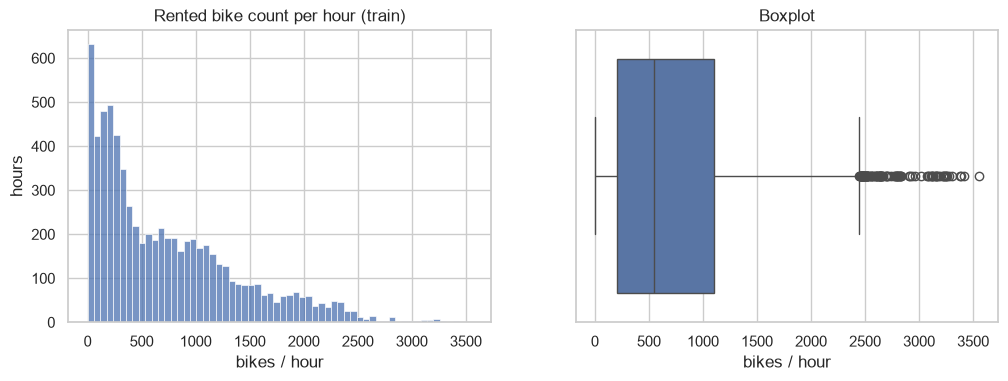

In [11]:
# ขั้น 4.2 — distribution ของ target: เบ้แค่ไหน และมี outlier ตามเกณฑ์ IQR กี่แถว
y = train["rented_bike_count"]
print(f"skewness = {y.skew():.2f} | ยอด = 0: {(y == 0).sum()} แถว ({(y == 0).mean():.1%})")
q1, q3 = y.quantile([0.25, 0.75])
whisker = q3 + 1.5 * (q3 - q1)          # เกณฑ์ outlier มาตรฐานของ boxplot
print(f"หนวดขวาของ boxplot (Q3 + 1.5·IQR) = {whisker:.1f} คัน/ชม. | แถวที่เกินหนวด: {(y > whisker).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(y, bins=60, ax=ax[0])
ax[0].set(title="Rented bike count per hour (train)", xlabel="bikes / hour", ylabel="hours")
sns.boxplot(x=y, ax=ax[1])
ax[1].set(title="Boxplot", xlabel="bikes / hour")
savefig("04_target_distribution.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- histogram เบ้ขวาชัดเจน: ชั่วโมงส่วนใหญ่มียอดไม่กี่ร้อยคัน และมีหางยาวไปถึง ~3,500 คัน (skewness ≈ 1.08)
- แท่งแรก (ใกล้ 0) สูงที่สุด ส่วนหนึ่งมาจาก **240 แถว (3.4%) ที่ยอดเป็น 0 พอดี** · boxplot มีจุดเกินหนวดขวา (> 2,443.5 คัน) **102 แถว**

**ตัดสินใจ:** ยอดเช่าที่เป็น 0 น่าสงสัย (ทั้งเมืองไม่มีใครเช่าเลยสักคันในชั่วโมงนั้น?) → ตรวจกับ `functioning_day` ใน 4.3 · ความเบ้ + หางยาว → ใช้ **MAE** เป็นเมตริกหลัก (RMSE ยกกำลังสองค่าคลาดเคลื่อน ชั่วโมงหางขวาไม่กี่ชั่วโมงจะครอบงำคะแนน)

### 4.3 `functioning_day` — ชั่วโมงที่ระบบปิด
**โค้ดทำอะไร:**
- สรุปยอดเช่าแยกตาม `functioning_day` (จำนวนแถว, ค่าเฉลี่ย, min, max)
- นับจำนวนแถวที่ระบบปิดต่อวัน เพื่อดูว่าปิดทั้งวันหรือปิดบางชั่วโมง
- เช็คว่าแถวที่ยอด = 0 ทั้งหมดตรงกับช่วงที่ระบบปิดหรือไม่

In [12]:
# ขั้น 4.3 — ยอด = 0 มาจากไหน: ถ้ามาจากชั่วโมงที่ระบบปิดทั้งหมด ก็เป็นกฎตายตัว ไม่ต้องให้โมเดลเรียน
print(train.groupby("functioning_day")["rented_bike_count"].agg(["count", "mean", "min", "max"]).round(1), "\n")

closed = train[train["functioning_day"] == "No"]
print("วันที่ระบบปิด (จำนวนชั่วโมงที่ปิด):")
print(closed.groupby(closed["date"].dt.strftime("%Y-%m-%d")).size().to_dict(), "\n")

zero = train["rented_bike_count"] == 0
print("แถวยอด = 0 ที่ระบบปิด:", (zero & (train["functioning_day"] == "No")).sum(), "/", zero.sum())

                 count   mean  min   max
functioning_day                         
No                 240    0.0    0     0
Yes               6768  756.8    2  3556 

วันที่ระบบปิด (จำนวนชั่วโมงที่ปิด):
{'2018-04-11': 24, '2018-05-10': 24, '2018-09-18': 24, '2018-09-28': 24, '2018-09-30': 24, '2018-10-02': 24, '2018-10-04': 24, '2018-10-09': 24, '2018-11-06': 24, '2018-11-09': 24} 

แถวยอด = 0 ที่ระบบปิด: 240 / 240


**ผลลัพธ์ (เห็นอะไร):**
- ชั่วโมงที่ `functioning_day = No` มี 240 แถว **ยอดเช่าเป็น 0 ทุกแถว** (mean = min = max = 0)
- ใน train ระบบปิด **ทั้งวัน (24 ชม.) 10 วัน** ช่วง เม.ย.–พ.ย. 2018 (น่าจะเป็นวันปิดปรับปรุงระบบ)
- แถวยอด = 0 ทั้ง 240 แถว **คือแถวที่ระบบปิดทั้งหมด** — ชั่วโมงที่ระบบเปิดไม่มียอด 0 เลย

**ตัดสินใจ: ตัดแถว `functioning_day = No` ออก** และประกาศขอบเขตว่าโมเดลใช้กับชั่วโมงที่ระบบเปิดเท่านั้น (ตามขั้น 1)
- เหตุผล: ถ้าเก็บไว้ โมเดลจะเรียนกฎ "ปิด → 0" ที่ผู้ให้บริการรู้ล่วงหน้าอยู่แล้ว แถวเหล่านี้ทายเป็น 0 ได้ถูกฟรีๆ จึงดึง MAE ให้ต่ำลงแบบไม่มีความหมาย และบังคับให้โมเดลเสียความสามารถไปเรียนกฎที่ไม่ได้มาจากอากาศ/เวลา
- ตัดได้ทั้ง train **และ test** เพราะเป็นกฎที่นิยามขอบเขตของปัญหา (ไม่ได้เรียนค่าอะไรจากข้อมูล) — ทำจริงใน `02_modeling` ขั้น 5
- หลังตัด คอลัมน์ `functioning_day` จะมีค่าเดียว → ไม่ใช้เป็น feature

### 4.4 Distribution ของยอดเช่าหลังตัดชั่วโมงที่ระบบปิด
**โค้ดทำอะไร:** สร้าง `train_op` (operating hours) แล้วใช้ตัวแปรนี้ตลอดส่วนที่เหลือของ EDA · คำนวณ mean และ median ของยอดเช่า แล้ววาด histogram พร้อมเส้นทั้งสอง (ดูว่าเบ้แค่ไหน → เลือกเมตริกและการแปลง target)

แถว: 7,008 -> 6,768 (ตัด 240) | วัน: 282
min = 2 | ยอด = 0: 0 แถว | skewness = 1.07
mean = 756.8 | median = 582.5 | skewness ของ log1p(y) = -0.80


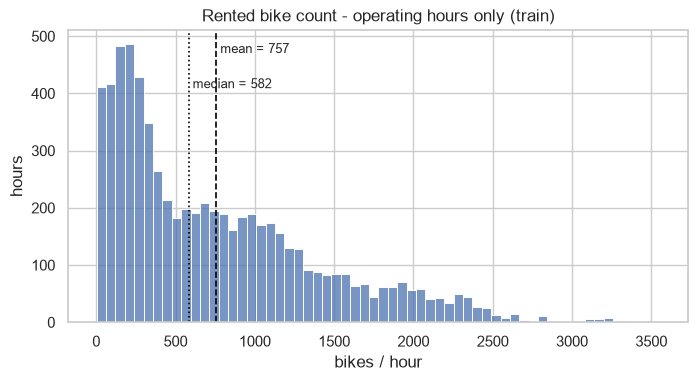

In [13]:
# ขั้น 4.4 — distribution หลังตัดชั่วโมงที่ระบบปิด (ขอบเขตของโมเดล = เฉพาะชั่วโมงที่ระบบเปิด)
train_op = train[train["functioning_day"] == "Yes"].reset_index(drop=True)
y_op = train_op["rented_bike_count"]
mean_y, median_y = y_op.mean(), y_op.median()
print(f"แถว: {len(train) :,} -> {len(train_op):,} (ตัด {len(train) - len(train_op)}) | วัน: {train_op['date'].nunique()}")
# เทียบ skewness ของ y กับ log1p(y) — ใช้ตัดสินใจลองแปลง target ในขั้น 11
print(f"min = {y_op.min()} | ยอด = 0: {(y_op == 0).sum()} แถว | skewness = {y_op.skew():.2f}")
print(f"mean = {mean_y:.1f} | median = {median_y:.1f} | skewness ของ log1p(y) = {np.log1p(y_op).skew():.2f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.histplot(y_op, bins=60, ax=ax)
for v, name, ls in [(median_y, "median", ":"), (mean_y, "mean", "--")]:
    ax.axvline(v, color="black", ls=ls, lw=1.2)
    ax.text(v, ax.get_ylim()[1] * (0.92 if name == "mean" else 0.80), f" {name} = {v:.0f}", fontsize=9)
ax.set(title="Rented bike count - operating hours only (train)", xlabel="bikes / hour", ylabel="hours")
savefig("04_target_operating_hours.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- เหลือ **6,768 แถว (282 วัน)** · ยอดต่ำสุด = 2 คัน → **ไม่มีค่า 0 เหลืออยู่เลย** · ยังเบ้ขวา (skewness ≈ 1.07)
- mean = **756.8** คัน/ชม. สูงกว่า median = **582.5** ราว 30% → หางขวา (ชั่วโมงพีคไม่กี่ชั่วโมงที่ยอดสูงมาก) ดึงค่าเฉลี่ยขึ้น
- ถ้าแปลงเป็น `log1p(y)` ความเบ้กลับด้านเป็น ≈ −0.80 (เบ้ซ้าย) → log แก้ความเบ้ได้แต่ "เกินไป" ไม่ได้ทำให้สมมาตร

**ตัดสินใจ:**
- เมตริกหลักใช้ **MAE** (คัน/ชม.) — ตีความตรงๆ ว่า "ทายคลาดเฉลี่ยกี่คัน" และไม่ถูกหางขวาครอบงำเหมือน RMSE · รายงาน RMSE และ R² เป็นเมตริกรอง
- โมเดลหลักไม่ต้องแปลง target (tree-based ไม่สนความเบ้) · จะลอง `log1p` กับโมเดลเชิงเส้นเป็นทางเลือกในขั้น 11 แล้วให้ CV ตัดสิน

### 4.5 ยอดเช่า × ชั่วโมง แยกประเภทวัน
**โค้ดทำอะไร:** จัดแต่ละวันเป็น 3 ประเภท — `weekday` (จ.–ศ. ที่ไม่ใช่วันหยุด), `weekend` (ส.–อา.), `holiday` (วันหยุดนักขัตฤกษ์) แล้วหาค่าเฉลี่ยยอดเช่าในแต่ละชั่วโมง วาดเป็น line plot

จำนวนวันแต่ละประเภท: {'holiday': 11, 'weekday': 191, 'weekend': 80}
day_type  holiday  weekday  weekend
hour                               
0           668.0    521.0    703.0
4           182.0    124.0    183.0
5           126.0    156.0    133.0
8           499.0   1381.0    456.0
10          607.0    554.0    596.0
13          958.0    717.0    948.0
17         1104.0   1220.0   1238.0
18         1097.0   1810.0   1204.0
22          823.0   1038.0    903.0


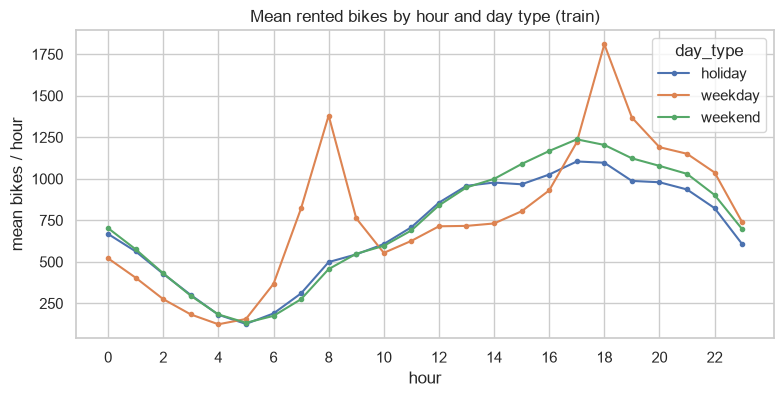

In [14]:
# ขั้น 4.5 — รูปแบบรายชั่วโมงแยกประเภทวัน: ใช้เลือกวิธี encode ชั่วโมงและสร้าง feature วันหยุด
dow = train_op["date"].dt.dayofweek          # 0 = จันทร์ ... 6 = อาทิตย์
# วันหยุดนักขัตฤกษ์มาก่อนวันเสาร์-อาทิตย์ → วันหยุดที่ตรงกับวันธรรมดาถูกนับเป็น holiday
day_type = np.select([train_op["holiday"] == "Holiday", dow >= 5], ["holiday", "weekend"], "weekday")
hourly = train_op.assign(day_type=day_type).pivot_table(
    index="hour", columns="day_type", values="rented_bike_count", aggfunc="mean")

print("จำนวนวันแต่ละประเภท:", train_op.assign(day_type=day_type).groupby("day_type")["date"].nunique().to_dict())
print(hourly.loc[[0, 4, 5, 8, 10, 13, 17, 18, 22]].round(0))

fig, ax = plt.subplots(figsize=(9, 4))
hourly.plot(ax=ax, marker="o", ms=3)
ax.set(title="Mean rented bikes by hour and day type (train)", xlabel="hour", ylabel="mean bikes / hour", xticks=range(0, 24, 2))
savefig("04_hourly_by_daytype.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- **วันทำงาน (weekday, 191 วัน)** มีพีค 2 ครั้งแหลมชัด: **8:00** (~1,380 คัน) ไปทำงาน/เรียน และสูงสุดที่ **18:00** (~1,810 คัน) ขากลับ — สูงกว่าช่วงกลางวัน (13:00 ~720) ราว 2.5 เท่า และมีหลุมตอน 10:00 → รูปแบบการใช้เพื่อเดินทาง (commute)
- **วันหยุดสุดสัปดาห์ (80 วัน) และวันหยุดนักขัตฤกษ์ (11 วัน)** เส้นรูปร่างเดียวกัน: ไม่มีพีคเช้า ยอดค่อยๆ ขึ้นตลอดบ่ายและสูงสุดที่ **17:00** (weekend ~1,240, holiday ~1,100) แบบโค้งกว้าง → การใช้เพื่อพักผ่อน · ช่วงเที่ยงคืนยอดสูงกว่าวันทำงาน (~670–700 vs ~520)
- ทุกประเภทวันต่ำสุดตอน **4:00–5:00** (~125–135 คัน)
- วันหยุดนักขัตฤกษ์ทำตัวเหมือนวันเสาร์-อาทิตย์ → รวมเป็นแนวคิด "วันไม่ทำงาน" ได้

**ตัดสินใจ:**
- `hour` เป็นตัวแปรที่สำคัญมาก และความสัมพันธ์กับยอดเช่า **ไม่เป็นเส้นตรงและเป็นวงรอบ** (23:00 ใกล้ 0:00) → ขั้น 5 สร้าง `hour_sin`, `hour_cos` · ⚠️ sin/cos คู่เดียวเป็นคลื่นลูกเดียวต่อวัน จับ 2 พีค (8:00, 18:00) ไม่ได้ → สำหรับโมเดลเชิงเส้นต้องลอง `hour` แบบ one-hot ด้วย (ขั้น 5.4)
- รูปร่างเส้นขึ้นกับประเภทวัน (interaction ระหว่าง hour × weekend) → ขั้น 5 สร้าง `is_weekend` และแปลง `holiday` เป็น `is_holiday` · โมเดลเชิงเส้นจับ interaction เองไม่ได้ แต่ tree-based จับได้ — เป็นจุดที่คาดว่าโมเดลจะต่างกันในขั้น 10

### 4.6 ยอดเช่า × วันในสัปดาห์
**โค้ดทำอะไร:** ค่าเฉลี่ยยอดเช่าต่อชั่วโมงแยกตามวันในสัปดาห์ (ไม่แยกชั่วโมง) เพื่อดูว่าจำเป็นต้องมี feature วันในสัปดาห์ครบ 7 ค่าไหม หรือแค่ weekday/weekend พอ

{'Mon': 736.0, 'Tue': 749.0, 'Wed': 811.0, 'Thu': 743.0, 'Fri': 816.0, 'Sat': 750.0, 'Sun': 682.0}


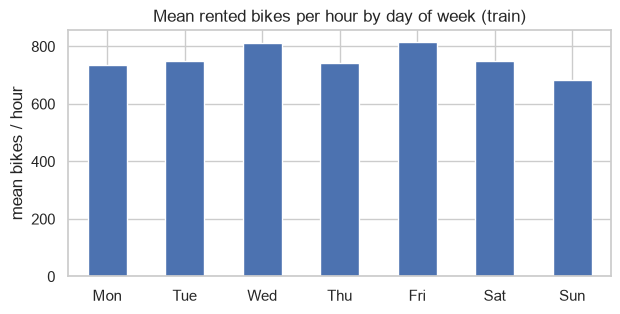

In [15]:
# ขั้น 4.6 — ยอดเฉลี่ยตามวันในสัปดาห์: ดูว่าต้องเก็บ day_of_week หรือแค่ "วันทำงาน/วันหยุด" ก็พอ
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = train_op.groupby(dow)["rented_bike_count"].mean().rename(index=dict(enumerate(dow_names)))
print(by_dow.round(0).to_dict())

fig, ax = plt.subplots(figsize=(7, 3.2))
by_dow.plot.bar(ax=ax, rot=0)
ax.set(title="Mean rented bikes per hour by day of week (train)", xlabel="", ylabel="mean bikes / hour")
savefig("04_day_of_week.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):** ค่าเฉลี่ยทั้งวันของแต่ละวันต่างกันไม่มาก (~680–820 คัน/ชม.) — อาทิตย์ต่ำสุด, พุธ/ศุกร์สูงสุด
เทียบกับ 4.5: ความต่างหลักของวันหยุด vs วันทำงานคือ **"รูปร่าง"** ของเส้นรายชั่วโมง ไม่ใช่ "ระดับ" ของทั้งวัน

**ตัดสินใจ:** สร้างทั้ง `day_of_week` และ `is_weekend` ในขั้น 5 แต่คาดว่า `is_weekend` จะมีประโยชน์กว่า · ให้ feature selection (ขั้น 7) เป็นผู้ตัดสินแทนการเดา

### 4.7 ยอดเช่า × ฤดู และ × อุณหภูมิ
**โค้ดทำอะไร:**
- ซ้าย: boxplot ยอดเช่าแยกตามฤดู
- ขวา: scatter ยอดเช่า vs อุณหภูมิ (จุดโปร่งแสงเพราะมี 6,768 จุด) + เส้นค่าเฉลี่ยของอุณหภูมิเป็นช่วงละ 5 °C เพื่อดูรูปร่างความสัมพันธ์

           mean  median   max
seasons                      
Winter    230.0   212.0   929
Spring    774.0   632.0  3251
Summer   1037.0   909.0  3556
Autumn    957.0   907.0  3277 

              mean  size
temp_c                  
(-20, -15]   111.0    11
(-15, -10]   155.0   148
(-10, -5]    180.0   363
(-5, 0]      234.0   541
(0, 5]       337.0   828
(5, 10]      544.0   795
(10, 15]     778.0   739
(15, 20]     927.0   941
(20, 25]    1080.0  1190
(25, 30]    1258.0   810
(30, 35]    1145.0   330
(35, 40]     912.0    72


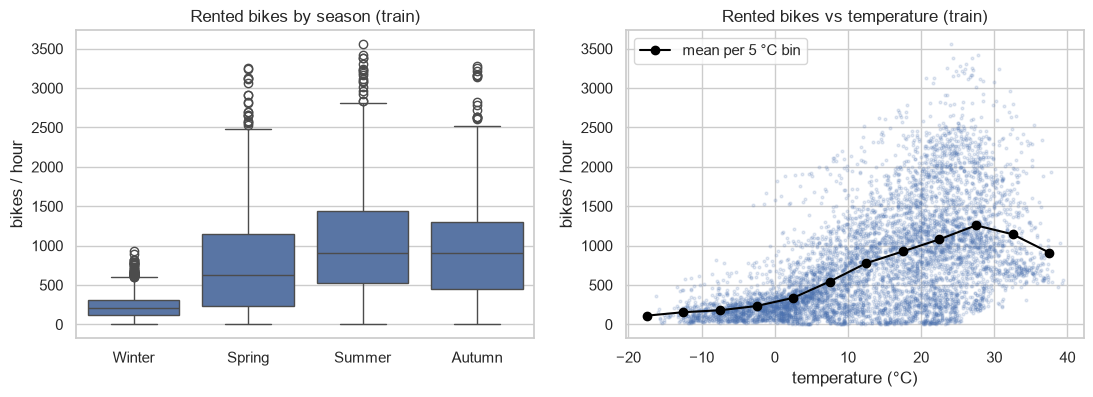

In [16]:
# ขั้น 4.7 — ฤดูและอุณหภูมิ: ความสัมพันธ์กับยอดเช่าเป็นเส้นตรงหรือโค้ง (มีผลต่อการเลือกโมเดล)
season_order = ["Winter", "Spring", "Summer", "Autumn"]
print(train_op.groupby("seasons")["rented_bike_count"].agg(["mean", "median", "max"]).loc[season_order].round(0), "\n")

# แบ่งอุณหภูมิเป็นช่วงละ 5 °C แล้วหาค่าเฉลี่ย → เห็นรูปร่างความสัมพันธ์ชัดกว่า scatter อย่างเดียว
temp_bin = pd.cut(train_op["temp_c"], bins=range(-20, 45, 5))
temp_mean = train_op.groupby(temp_bin, observed=True)["rented_bike_count"].agg(["mean", "size"])
print(temp_mean.round(0))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=train_op, x="seasons", y="rented_bike_count", order=season_order, ax=ax[0])
ax[0].set(title="Rented bikes by season (train)", xlabel="", ylabel="bikes / hour")
ax[1].scatter(train_op["temp_c"], train_op["rented_bike_count"], s=4, alpha=0.15)
ax[1].plot([iv.mid for iv in temp_mean.index], temp_mean["mean"], color="black", marker="o", label="mean per 5 °C bin")
ax[1].set(title="Rented bikes vs temperature (train)", xlabel="temperature (°C)", ylabel="bikes / hour")
ax[1].legend()
savefig("04_season_temperature.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- **ฤดูหนาวต่ำกว่าฤดูอื่นมาก** (เฉลี่ย ~230 คัน/ชม. เทียบกับ ~770–1,040 ในฤดูอื่น) และ **ยอดสูงสุดของฤดูหนาวแค่ 929** ต่ำกว่าค่าเฉลี่ยของ Summer
- Summer กับ Autumn มัธยฐานใกล้กัน (~910) · Spring กระจายกว้าง (ต้นฤดูยังหนาว ปลายฤดูอุ่น) มัธยฐานต่ำกว่า
- ยอดเช่าเพิ่มขึ้นตามอุณหภูมิจนถึงราว **25–30 °C** แล้ว **ลดลง** เมื่อร้อนเกิน 30 °C → ความสัมพันธ์เป็น **โค้งคว่ำ ไม่ใช่เส้นตรง**
- scatter ในอุณหภูมิเดียวกันยังกระจายกว้างมาก (แนวตั้ง) — ส่วนหนึ่งมาจาก `hour` (กลางคืนยอดต่ำแม้อากาศดี)

**ตัดสินใจ:**
- ความสัมพันธ์โค้ง → คาดว่าโมเดลเชิงเส้น (Linear Regression) จะเสียเปรียบ tree-based/kNN — ใช้อธิบายผลในขั้น 10
- `seasons` สัมพันธ์กับอุณหภูมิสูง (ข้อมูลซ้อนกัน) แต่ยังเก็บไว้ทั้งคู่ ให้ขั้น 7 ตัดสิน
- ⚠️ เชื่อมกับข้อสังเกตในขั้น 3.2: test มีฤดูหนาว ~31.5% ซึ่งยอดต่ำ ค่าคลาดเคลื่อนเป็นคันจึงมักเล็ก → MAE รวมของ test อาจดูดีเกินจริง ต้องดูแยกฤดูด้วย

### 4.8 ฝนและหิมะ (zero-inflated)
**โค้ดทำอะไร:** สำหรับ `rainfall_mm` และ `snowfall_cm` นับสัดส่วนชั่วโมงที่เป็น 0 และเทียบยอดเช่าเฉลี่ยระหว่างชั่วโมงที่ "มี" กับ "ไม่มี" ฝน/หิมะ · สำหรับฝน ดูเพิ่มว่าปริมาณมาก/น้อยต่างกันแค่ไหน

rainfall_mm  = 0: 93.9% | mean count: =0 -> 795, >0 -> 164
snowfall_cm  = 0: 95.6% | mean count: =0 -> 783, >0 -> 182

ยอดเช่าเฉลี่ยของชั่วโมงหิมะ > 0 vs ฤดูหนาวทั้งหมด: 182 vs 230
              mean  size
rainfall_mm             
0            795.0  6355
(0,1]        223.0   215
(1,5]        106.0   149
>5            78.0    49


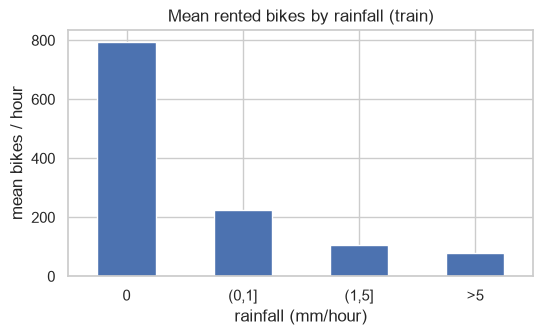

In [17]:
# ขั้น 4.8 — ฝนและหิมะเป็น 0 เกือบตลอด (zero-inflated) → เทียบ "มี vs ไม่มี" สำคัญกว่าดูปริมาณ
for col in ["rainfall_mm", "snowfall_cm"]:
    has = train_op[col] > 0
    print(f"{col:<12} = 0: {(~has).mean():.1%} | mean count: =0 -> {train_op.loc[~has, 'rented_bike_count'].mean():.0f}, "
          f">0 -> {train_op.loc[has, 'rented_bike_count'].mean():.0f}")

# หิมะตกแค่ในฤดูหนาว → เทียบกับฤดูหนาวด้วยกัน เพื่อแยกผลของหิมะออกจากผลของความหนาว
print("\nยอดเช่าเฉลี่ยของชั่วโมงหิมะ > 0 vs ฤดูหนาวทั้งหมด:",
      round(train_op.loc[train_op["snowfall_cm"] > 0, "rented_bike_count"].mean()),
      "vs", round(train_op.loc[train_op["seasons"] == "Winter", "rented_bike_count"].mean()))

rain_level = pd.cut(train_op["rainfall_mm"], [-0.1, 0, 1, 5, 40], labels=["0", "(0,1]", "(1,5]", ">5"])
print(train_op.groupby(rain_level, observed=True)["rented_bike_count"].agg(["mean", "size"]).round(0))

fig, ax = plt.subplots(figsize=(6, 3.2))
train_op.groupby(rain_level, observed=True)["rented_bike_count"].mean().plot.bar(ax=ax, rot=0)
ax.set(title="Mean rented bikes by rainfall (train)", xlabel="rainfall (mm/hour)", ylabel="mean bikes / hour")
savefig("04_rainfall.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- ฝนเป็น 0 ใน **~94%** ของชั่วโมง · หิมะเป็น 0 ใน **~96%** → ส่วนใหญ่เป็นศูนย์ (zero-inflated)
- ชั่วโมงที่มีฝน ยอดเช่าเฉลี่ยตกจาก ~795 เหลือ **~164** คัน/ชม. (ลดลง ~80%) และแม้ฝนแค่ ≤ 1 มม. ยอดก็ตกแรงแล้ว — กราฟแท่งแสดงว่า **"มีฝนหรือไม่"** ส่งผลมากกว่า "ฝนมากแค่ไหน"
- ชั่วโมงที่มีหิมะยอดต่ำ (~182) แต่ใกล้กับค่าเฉลี่ยฤดูหนาวทั้งฤดู (~230) → ข้อมูลของหิมะส่วนใหญ่ถูก `seasons`/`temp_c` อธิบายไปแล้ว

**ตัดสินใจ:**
- ขั้น 5 สร้าง **`is_raining` = (`rainfall_mm` > 0)** แยกผล "มีฝน" ออกจาก "ปริมาณฝน" ซึ่งโมเดลเชิงเส้นจับเองไม่ได้
- ไม่สร้าง `is_snowing` (ข้อมูลซ้ำกับฤดูหนาว) — เก็บ `snowfall_cm` ดิบไว้ให้ feature selection ตัดสิน

### 4.9 Correlation ระหว่าง feature
**โค้ดทำอะไร:** คำนวณ Pearson correlation ของตัวแปรตัวเลขทั้งหมด (รวม target) วาดเป็น heatmap แล้วดึงคู่ที่ |r| > 0.8 ออกมา
⚠️ Pearson วัดเฉพาะความสัมพันธ์ **เชิงเส้น** — ความสัมพันธ์โค้ง (เช่น อุณหภูมิ vs ยอดเช่าใน 4.7) จะได้ค่า r ต่ำกว่าความจริง

คู่ที่ |r| > 0.8:
 temp_c  dew_point_c    0.911
dtype: float64 

r กับ rented_bike_count:
 temp_c                0.55
hour                  0.44
dew_point_c           0.38
solar_radiation_mj    0.28
visibility_10m        0.22
humidity_pct         -0.22
wind_speed_ms         0.16
snowfall_cm          -0.15
rainfall_mm          -0.13
Name: rented_bike_count, dtype: float64


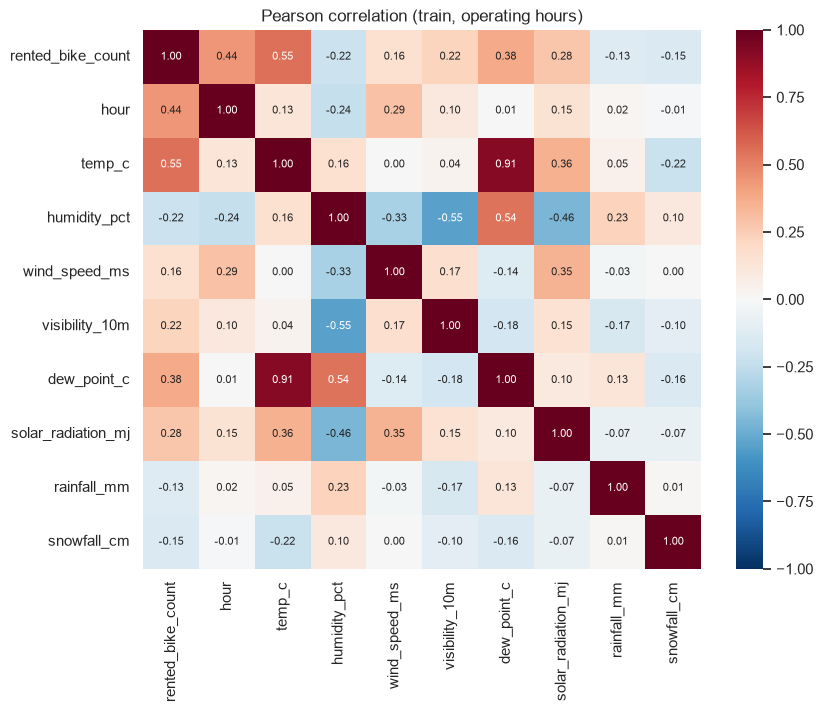

In [18]:
# ขั้น 4.9 — correlation: หาคู่ feature ที่ซ้ำซ้อนกัน (|r| > 0.8) และ feature ที่สัมพันธ์กับ target มากที่สุด
num_cols = ["rented_bike_count", "hour", "temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m",
            "dew_point_c", "solar_radiation_mj", "rainfall_mm", "snowfall_cm"]
corr = train_op[num_cols].corr()          # Pearson = วัดความสัมพันธ์เชิงเส้นเท่านั้น

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()   # เก็บแค่สามเหลี่ยมบน ไม่นับคู่ซ้ำ
print("คู่ที่ |r| > 0.8:\n", pairs[pairs.abs() > 0.8].round(3), "\n")
print("r กับ rented_bike_count:\n", corr["rented_bike_count"].drop("rented_bike_count").sort_values(key=abs, ascending=False).round(2))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
ax.set(title="Pearson correlation (train, operating hours)")
savefig("04_correlation.png")
plt.show()

**ผลลัพธ์ (เห็นอะไร):**
- มีคู่เดียวที่ |r| > 0.8 คือ **`temp_c` กับ `dew_point_c` (r ≈ 0.91)** — dew point คำนวณจากอุณหภูมิและความชื้น จึงแทบเป็นข้อมูลซ้ำ
- คู่ที่สัมพันธ์ปานกลาง: `humidity_pct` กับ `visibility_10m` (≈ −0.55, ชื้นมาก → หมอก → มองเห็นได้ไม่ไกล), `humidity_pct` กับ `dew_point_c` (≈ 0.54), `humidity_pct` กับ `solar_radiation_mj` (≈ −0.46)
- กับ target: `temp_c` สัมพันธ์สูงสุด (≈ 0.55) ตามด้วย `hour` (≈ 0.44) และ `dew_point_c` (≈ 0.38) · ฝน/หิมะมี r ต่ำ (≈ −0.13, −0.15) ทั้งที่ 4.8 แสดงว่ามีผลแรง → เพราะความสัมพันธ์ไม่เป็นเส้นตรง (zero-inflated) ยืนยันว่าควรสร้าง `is_raining`

**ตัดสินใจ:**
- **ไม่ตัด** `dew_point_c` ตอนนี้ — ให้ขั้น 7 (feature selection) ตัดสิน · คาดว่า L1 จะเลือกไว้แค่ตัวเดียวในคู่นี้
- ความซ้ำซ้อนระหว่างตัวแปรอากาศ (temp/dew/humidity/visibility/solar) เป็นเหตุผลที่ PCA (ขั้น 8) อาจบีบมิติได้

### 4.10 Outlier (IQR) + ความชื้น 0% (outlier จากเซนเซอร์)
**โค้ดทำอะไร:** นับ outlier ของแต่ละคอลัมน์ตัวเลขด้วยกฎ IQR (นอกช่วง Q1 − 1.5·IQR ถึง Q3 + 1.5·IQR) แล้วแสดงขอบเขตคู่กับ min/max จริง

In [19]:
# ขั้น 4.10 — นับ outlier ทุกคอลัมน์ด้วยเกณฑ์ IQR (Q1 − 1.5·IQR, Q3 + 1.5·IQR)
# outlier ตามสถิติไม่ได้แปลว่าผิด → ต้องดูต่อว่าเป็นไปได้ทางกายภาพหรือไม่ก่อนตัดสินใจลบ
rows = []
for c in num_cols:
    q1, q3 = train_op[c].quantile([0.25, 0.75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    n_out = ((train_op[c] < lo) | (train_op[c] > hi)).sum()
    rows.append({"column": c, "lower": lo, "upper": hi, "min": train_op[c].min(), "max": train_op[c].max(),
                 "n_outlier": n_out, "pct": 100 * n_out / len(train_op)})
pd.DataFrame(rows).set_index("column").round(2)

,lower,upper,min,max,n_outlier,pct
column,,,,,,
rented_bike_count,-1116.00,2460.00,2.0,3556.00,95,1.40
hour,-11.50,34.50,0.0,23.00,0,0.00
temp_c,-25.25,51.95,-16.2,39.40,0,0.00
humidity_pct,-5.00,123.00,0.0,98.00,0,0.00
wind_speed_ms,-1.20,4.40,0.0,7.40,110,1.63
visibility_10m,-639.00,3577.00,27.0,2000.00,0,0.00
dew_point_c,-34.80,46.00,-30.6,27.20,0,0.00
solar_radiation_mj,-1.42,2.38,0.0,3.52,486,7.18
rainfall_mm,0.00,0.00,0.0,35.00,413,6.10


**ผลลัพธ์ (เห็นอะไร):**
- `rainfall_mm` (~6%) และ `snowfall_cm` (~4%): IQR = 0 เพราะส่วนใหญ่เป็น 0 → **ทุกชั่วโมงที่มีฝน/หิมะกลายเป็น "outlier"** — กฎ IQR ใช้ไม่ได้กับตัวแปร zero-inflated
- `solar_radiation_mj` (~7%) และ `wind_speed_ms` (~1.6%): ค่าที่เกินคือวันแดดจัด/ลมแรง ซึ่งอยู่ในช่วงที่เป็นไปได้จริง
- `rented_bike_count` (~1.4%): ชั่วโมงที่เช่าเกิน ~2,460 คัน = พีคเย็นวันทำงานในวันอากาศดี → เป็นเหตุการณ์จริง และเป็นชั่วโมงที่ผู้ให้บริการต้องการให้ทำนายแม่นที่สุด
- `humidity_pct`: กฎ IQR ไม่นับเป็น outlier (ขอบล่าง −5 ต่ำกว่า 0) แต่ **min = 0%** เป็นไปไม่ได้ทางกายภาพ → ตรวจต่อด้านล่างด้วยความรู้โดเมน

**ตัดสินใจ: ไม่ตัด outlier ของสภาพอากาศและยอดเช่า** (ยกเว้นความชื้น 0% ด้านล่าง) — เป็นเหตุการณ์จริงที่โมเดลต้องเจอตอนใช้งาน (spec ให้ "พิจารณา" ไม่ได้บังคับให้ลบ) · ตัวแปรที่เบ้/สเกลใหญ่จะจัดการด้วย StandardScaler ใน Pipeline แทน

**โค้ดทำอะไร (ความชื้น = 0%):** ดูแถวที่ `humidity_pct == 0` ว่าเกิดวันไหน แล้ว **คำนวณความชื้นย้อนกลับจากอุณหภูมิและ dew point ของแถวเดียวกัน (ทีละแถว)** ด้วยสูตร Magnus
$RH \approx 100 \cdot \dfrac{\exp\left(\frac{17.625\,T_d}{243.04 + T_d}\right)}{\exp\left(\frac{17.625\,T}{243.04 + T}\right)}$
ถ้าความชื้นที่คำนวณได้ห่างจาก 0 มาก แปลว่าเซนเซอร์ความชื้นเสีย ไม่ใช่อากาศแห้งจริง = outlier จากเซนเซอร์อ่านค่าผิด

In [20]:
# ขั้น 4.10 (ต่อ) — ความชื้น 0% เป็นไปไม่ได้ในอากาศจริง → ตรวจด้วยฟิสิกส์ว่าเป็นค่าผิดของเซนเซอร์หรือไม่
def magnus_rh(t, td):
    # สูตร Magnus: คำนวณความชื้นสัมพัทธ์ (%) จากอุณหภูมิ t และ dew point td (°C)
    return 100 * np.exp(17.625 * td / (243.04 + td)) / np.exp(17.625 * t / (243.04 + t))

h0 = train_op[train_op["humidity_pct"] == 0].copy()
h0["rh_from_dew_point"] = magnus_rh(h0["temp_c"], h0["dew_point_c"]).round(1)
print("จำนวนแถว:", len(h0), "| วัน:", h0["date"].dt.strftime("%Y-%m-%d").value_counts().sort_index().to_dict())
# ยืนยันก่อนว่าสูตรใช้กับข้อมูลชุดนี้ได้ (แถวปกติต้องคลาดน้อย) แล้วค่อยใช้กับแถวความชื้น 0%
print("ตรวจสูตรกับแถวปกติ: |RH จริง − RH จากสูตร| เฉลี่ย =",
      round((train_op["humidity_pct"] - magnus_rh(train_op["temp_c"], train_op["dew_point_c"]))[train_op["humidity_pct"] > 0].abs().mean(), 2))
print("RH ที่คำนวณจาก dew point ของ 17 แถวนี้: min =", h0["rh_from_dew_point"].min(), "| max =", h0["rh_from_dew_point"].max())
h0[["date", "hour", "temp_c", "dew_point_c", "humidity_pct", "rh_from_dew_point", "rented_bike_count"]].head(8)

จำนวนแถว: 17 | วัน: {'2018-05-19': 1, '2018-05-21': 6, '2018-05-22': 4, '2018-05-27': 2, '2018-05-28': 4}
ตรวจสูตรกับแถวปกติ: |RH จริง − RH จากสูตร| เฉลี่ย = 0.24
RH ที่คำนวณจาก dew point ของ 17 แถวนี้: min = 33.1 | max = 71.7


,date,hour,temp_c,dew_point_c,humidity_pct,rh_from_dew_point,rented_bike_count
3151,2018-05-19,7,11.4,4.5,0,62.5,436
3194,2018-05-21,2,13.9,-2.1,0,33.1,262
3195,2018-05-21,3,13.0,-2.5,0,34.0,165
3196,2018-05-21,4,12.4,-3.4,0,33.1,113
3197,2018-05-21,5,11.9,-2.7,0,36.0,200
3198,2018-05-21,6,11.4,-2.0,0,39.2,467
3199,2018-05-21,7,12.3,-2.7,0,35.1,1135
3219,2018-05-22,3,15.5,10.4,0,71.6,406


**ผลลัพธ์ (เห็นอะไร):**
- มี **17 แถว** ที่ความชื้น = 0% อยู่ในช่วง 19–28 พ.ค. 2018 (5 วัน)
- สูตร Magnus ใช้ได้จริงกับข้อมูลชุดนี้ (แถวปกติคลาดจากค่าจริงเฉลี่ยไม่ถึง 1 จุดเปอร์เซ็นต์) แต่แถวที่ความชื้น = 0 คำนวณย้อนกลับได้ **33–72%** → ความชื้น 0% **ขัดกับอุณหภูมิและ dew point ในแถวเดียวกัน** = ค่าผิดจากเซนเซอร์ (ไม่ใช่เหตุการณ์จริง) → เป็น **outlier** จากเซนเซอร์อ่านค่าผิด และไม่รู้ความชื้นจริงของ 17 แถวนี้

**ตัดสินใจ:** ต่างจาก outlier อื่นที่เป็นเหตุการณ์จริง ค่านี้ **ผิด** จึงไม่ควรปล่อยให้โมเดลเรียนว่าอากาศแห้งสนิท และแก้เป็นค่าที่ถูกไม่ได้ → **ลบค่า 0 ทิ้งให้เป็น missing value** (4.11) แล้วเติมทีหลัง · ไม่ลบทั้งแถวเพราะค่าอื่นในแถวยังถูกต้อง

### 4.11 ทำ outlier ความชื้น 0% ให้เป็น missing value (ไฟล์ใหม่)
**โค้ดทำอะไร:**
- อ่านไฟล์ดิบเป็นข้อความทีละบรรทัด แล้ว **ลบเฉพาะช่องความชื้นที่เป็น `0`** ให้ว่าง ส่วนอื่น (encoding, วันที่, ตัวเลข, ขึ้นบรรทัด) คงไว้ทุก byte
- บันทึกเป็น `config.PROCESSED_CSV` (`data/processed/`) · ไฟล์ดิบใน `data/raw/` ไม่ถูกแก้
- ตรวจว่าต่างจากไฟล์ดิบแค่ 17 ช่องนี้ แล้วโหลดกลับมาดู `info()` ว่าเห็น missing value หรือไม่

**ทำไมใช้ไฟล์ทั้งชุดได้โดยไม่รั่ว:** เป็นกฎตายตัวทีละแถว (ค่า 0 → ว่าง) ไม่ได้คำนวณสถิติจากข้อมูล · ค่าที่ใช้เติมช่องว่าง (median) เรียนจาก train ใน Pipeline ของ `02_modeling` ขั้น 6

In [21]:
# ขั้น 4.11 — ทำ outlier ความชื้น 0% (4.10) ให้เป็น missing value: เขียนไฟล์ใหม่ที่ช่องนั้นว่าง แล้วโหลดกลับมาตรวจ
# แก้เป็นข้อความทีละช่อง (ไม่ใช้ to_csv) → ส่วนอื่นของไฟล์เหมือนไฟล์ดิบทุก byte · ไฟล์ดิบไม่ถูกแก้
raw_bytes = config.RAW_CSV.read_bytes()
lines = raw_bytes.decode(config.RAW_ENCODING).splitlines(keepends=True)
h = lines[0].rstrip("\r\n").split(",").index("Humidity(%)")   # ตำแหน่งคอลัมน์ความชื้น
out, n_blank = [lines[0]], 0
for line in lines[1:]:
    body = line.rstrip("\r\n")
    cells = body.split(",")
    if cells[h] == "0":
        cells[h] = ""            # ความชื้น 0% (ค่าผิด) → ช่องว่าง = missing value
        n_blank += 1
    out.append(",".join(cells) + line[len(body):])   # คงตัวขึ้นบรรทัดเดิม
new_bytes = "".join(out).encode(config.RAW_ENCODING)
config.PROCESSED_CSV.parent.mkdir(exist_ok=True)
config.PROCESSED_CSV.write_bytes(new_bytes)

# ตรวจ: ลบไป 17 ตัวอักษร (เลข 0) พอดี และเมื่อโหลดแล้ว ต่างจากไฟล์ดิบแค่ 17 ช่องของความชื้น
raw_df = pd.read_csv(config.RAW_CSV, encoding=config.RAW_ENCODING).rename(columns=config.COLUMN_MAP)
new_df = pd.read_csv(config.PROCESSED_CSV, encoding=config.RAW_ENCODING).rename(columns=config.COLUMN_MAP)
changed = (raw_df != new_df) & ~(raw_df.isna() & new_df.isna())
assert n_blank == len(raw_bytes) - len(new_bytes) == changed.values.sum() == changed["humidity_pct"].sum()
print(f"ความชื้น 0% → ช่องว่าง: {n_blank} ช่อง | ไฟล์ใหม่: {config.PROCESSED_CSV.relative_to(ROOT).as_posix()}")
print("missing value ต่อคอลัมน์:", new_df.isnull().sum()[lambda s: s > 0].to_dict())
new_df.info()

ความชื้น 0% → ช่องว่าง: 17 ช่อง | ไฟล์ใหม่: data/processed/SeoulBikeData_humidity0_to_nan.csv
missing value ต่อคอลัมน์: {'humidity_pct': 17}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                8760 non-null   object 
 1   rented_bike_count   8760 non-null   int64  
 2   hour                8760 non-null   int64  
 3   temp_c              8760 non-null   float64
 4   humidity_pct        8743 non-null   float64
 5   wind_speed_ms       8760 non-null   float64
 6   visibility_10m      8760 non-null   int64  
 7   dew_point_c         8760 non-null   float64
 8   solar_radiation_mj  8760 non-null   float64
 9   rainfall_mm         8760 non-null   float64
 10  snowfall_cm         8760 non-null   float64
 11  seasons             8760 non-null   object 
 12  holiday             8760 non-null   object 
 13  functioning_

**ผลลัพธ์:**
- ไฟล์ใหม่ต่างจากไฟล์ดิบแค่ **17 ช่อง** (ความชื้น 0% → ว่าง) · ไฟล์เล็กลง 17 byte พอดี ส่วนอื่นเหมือนเดิมทุก byte
- `info()` ของไฟล์ใหม่: `humidity_pct` **8,743 non-null** จาก 8,760 แถว → **missing value 17 ค่า** · คอลัมน์อื่นครบ 8,760 · `humidity_pct` เปลี่ยนเป็น `float64` เพราะมี NaN

**ตัดสินใจ:** `02_modeling` โหลดไฟล์นี้แทนไฟล์ดิบ (ขั้น 5.1) แล้วให้ `SimpleImputer(strategy="median")` **ใน Pipeline** เติม missing value (ขั้น 6.2) เพื่อให้ค่ามัธยฐานเรียนจาก fold ของ train เท่านั้น

---
## สรุปขั้น 4 — การตัดสินใจที่ส่งต่อไป `02_modeling`

| ประเด็น | สิ่งที่พบ (train) | การตัดสินใจ | ทำที่ |
|---|---|---|---|
| `functioning_day = No` | 240 แถว (10 วันเต็ม) ยอด = 0 ทุกแถว | **ตัดออก** ทั้ง train/test + ประกาศขอบเขต | ขั้น 5 |
| ยอดเช่าหลังตัด | 6,768 แถว, ไม่มี 0 เหลือ, เบ้ขวา (skew ≈ 1.07), mean 756.8 > median 582.5 | y = `rented_bike_count` ดิบ · เมตริกหลัก **MAE** · ลอง `log1p` กับโมเดลเชิงเส้น | ขั้น 1, 11 |
| ชั่วโมง | พีค 8:00, 18:00 เฉพาะวันทำงาน, เป็นวงรอบ | `hour_sin`, `hour_cos`, `is_weekend`, `is_holiday` + ลอง `hour` one-hot กับโมเดลเชิงเส้น | ขั้น 5, 6 |
| วันในสัปดาห์ | ระดับทั้งวันต่างกันน้อย | สร้าง `day_of_week` ให้ FS ตัดสิน | ขั้น 5, 7 |
| อุณหภูมิ/ฤดู | สัมพันธ์แบบโค้ง พีค 25–30 °C, ฤดูหนาวต่ำมาก | เก็บทั้งคู่ + `month`, ให้ FS ตัดสิน | ขั้น 5, 7 |
| ฝน | 94% เป็น 0, มีฝน → ยอดลด ~80% | สร้าง `is_raining` | ขั้น 5 |
| `temp_c` vs `dew_point_c` | r ≈ 0.91 (คู่เดียวที่ > 0.8) | เก็บทั้งคู่ ให้ FS ตัดสิน | ขั้น 7 |
| outlier อากาศ/ยอดเช่า | เป็นเหตุการณ์จริง | **ไม่ตัด** | — |
| ความชื้น = 0% | 17 แถว · Magnus ได้ 33–72% → **outlier** จากเซนเซอร์ | 4.11 ไฟล์ใหม่ที่ช่องนี้ว่าง = **missing value** 17 ค่า · 6.2 median imputer ใน Pipeline | 4.11, ขั้น 5, 6 |
| สเกลต่างกันมาก | visibility 27–2,000 vs ตัวแปรอื่นหลักหน่วย | StandardScaler ใน Pipeline | ขั้น 6 |